# Лабораторная работа 7 — Кодирование и масштабирование

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** pandas, numpy, scikit-learn, matplotlib, seaborn

## Цель работы

Изучить методы кодирования категориальных признаков и масштабирования числовых, применить их к датасету GTZAN и оценить влияние на качество классификации.

## Теоретическое введение

### Кодирование категориальных признаков

Большинство алгоритмов ML работают только с числовыми данными, поэтому категориальные признаки необходимо преобразовать:

- **LabelEncoder** — присваивает каждой уникальной категории число (0, 1, 2, ...). Прост, но вносит ложный порядок.
- **OrdinalEncoder** — аналогичен LabelEncoder, но для нескольких столбцов одновременно. Подходит для ординальных признаков.
- **OneHotEncoder** — создаёт бинарный столбец для каждой категории. Избегает ложного порядка, но увеличивает размерность.

### Масштабирование числовых признаков

Признаки с разным масштабом могут искажать работу алгоритмов, использующих расстояния (KNN, SVM, логистическая регрессия).

- **StandardScaler** — Z-нормализация: $x' = \frac{x - \mu}{\sigma}$, результат: $\mu=0, \sigma=1$
- **MinMaxScaler** — масштабирование в [0, 1]: $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$
- **MaxAbsScaler** — масштабирование в [-1, 1] по максимальному абсолютному значению
- **Normalization (L2)** — каждое наблюдение нормируется к единичной длине вектора

### Когда какой метод?

| Метод | Когда использовать |
|-------|-------------------|
| StandardScaler | По умолчанию для линейных моделей, SVM, PCA |
| MinMaxScaler | Когда нужен фиксированный диапазон, для нейросетей |
| MaxAbsScaler | Для разреженных данных |
| Без масштабирования | Деревья и ансамбли (не чувствительны к масштабу) |

### Pipeline

**Pipeline** объединяет предобработку и модель в единый конвейер, предотвращая утечку данных при кросс-валидации.

## Загрузка и анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler, MaxAbsScaler, Normalizer
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
print(f'Размер: {df.shape}')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('length')

print(f'Категориальные ({len(cat_cols)}): {cat_cols}')
print(f'Числовые: {len(num_cols)}')

Размер: (1000, 60)
Категориальные (2): ['filename', 'label']
Числовые: 57


---
## 1. Кодирование категориального признака label

В GTZAN единственный категориальный признак — `label` (жанр). Продемонстрируем три метода кодирования.

### 1.1. LabelEncoder

In [3]:
le = LabelEncoder()
y_label = le.fit_transform(df['label'])

encoding_map = pd.DataFrame({'Жанр': le.classes_, 'Код': range(len(le.classes_))})
print('LabelEncoder: каждому жанру — уникальное число')
encoding_map

LabelEncoder: каждому жанру — уникальное число


,Жанр,Код
0,blues,0
1,classical,1
2,country,2
3,disco,3
4,hiphop,4
5,jazz,5
6,metal,6
7,pop,7
8,reggae,8
9,rock,9


### 1.2. OrdinalEncoder

In [4]:
oe = OrdinalEncoder()
y_ordinal = oe.fit_transform(df[['label']])
print(f'OrdinalEncoder: shape {y_ordinal.shape}')
print(f'Уникальные значения: {np.unique(y_ordinal).astype(int)}')
print('OrdinalEncoder аналогичен LabelEncoder, но работает с DataFrame')

OrdinalEncoder: shape (1000, 1)
Уникальные значения: [0 1 2 3 4 5 6 7 8 9]
OrdinalEncoder аналогичен LabelEncoder, но работает с DataFrame


### 1.3. OneHotEncoder

In [5]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
y_onehot = ohe.fit_transform(df[['label']])

ohe_df = pd.DataFrame(y_onehot, columns=ohe.get_feature_names_out())
print(f'OneHotEncoder: {y_onehot.shape[1]} бинарных столбцов (drop=first)')
ohe_df.head()

OneHotEncoder: 9 бинарных столбцов (drop=first)


,label_classical,label_country,label_disco,label_hiphop,label_jazz,label_metal,label_pop,label_reggae,label_rock
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


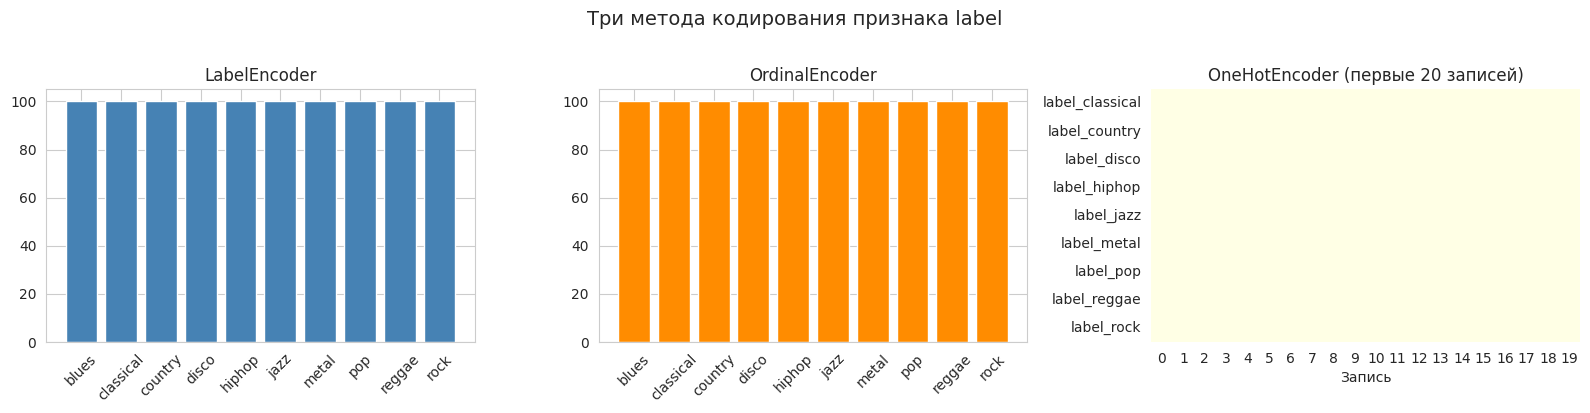

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(le.classes_, pd.Series(y_label).value_counts().sort_index(), color='steelblue')
axes[0].set_title('LabelEncoder', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(le.classes_, pd.Series(y_ordinal.ravel()).value_counts().sort_index(), color='darkorange')
axes[1].set_title('OrdinalEncoder', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(ohe_df.head(20).T, cmap='YlGn', ax=axes[2], cbar=False)
axes[2].set_title('OneHotEncoder (первые 20 записей)', fontsize=12)
axes[2].set_xlabel('Запись')

fig.suptitle('Три метода кодирования признака label', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация:** Для задачи классификации жанров будем использовать **LabelEncoder** — он создаёт компактную числовую метку класса. OneHotEncoder полезен, если label был бы входным признаком.

---
## 2. Масштабирование числовых признаков

Рассмотрим масштабы исходных данных — они сильно отличаются:

In [7]:
X = df[num_cols].copy()
y = le.fit_transform(df['label'])

scale_info = pd.DataFrame({
    'Признак': num_cols,
    'Min': X.min().values,
    'Max': X.max().values,
    'Mean': X.mean().values.round(4),
    'Std': X.std().values.round(4)
})
print('Примеры различий в масштабах:')
pd.concat([
    scale_info.loc[scale_info['Max'].nlargest(5).index],
    scale_info.loc[scale_info['Max'].nsmallest(5).index]
])

Примеры различий в масштабах:


,Признак,Min,Max,Mean,Std
9,rolloff_var,1.468612e+04,8.660900e+06,1.844345e+06,1.425085e+06
5,spectral_centroid_var,7.911251e+03,3.036843e+06,4.696916e+05,4.008995e+05
7,spectral_bandwidth_var,1.078719e+04,6.947848e+05,1.370792e+05,9.645567e+04
18,mfcc1_var,1.745714e+02,2.824344e+04,3.747875e+03,2.770558e+03
8,rolloff_mean,7.491406e+02,8.677673e+03,4.571549e+03,1.574792e+03
14,perceptr_mean,-7.149944e-03,5.786965e-03,-4.000000e-04,1.100000e-03
12,harmony_mean,-2.606458e-02,1.505448e-02,-4.000000e-04,1.700000e-03
3,rms_var,4.294372e-06,2.767948e-02,3.100000e-03,3.600000e-03
11,zero_crossing_rate_var,4.408679e-05,2.871840e-02,3.000000e-03,3.000000e-03
15,perceptr_var,8.299008e-07,4.744598e-02,5.700000e-03,6.500000e-03


### 2.1. Применяем 4 метода масштабирования

In [8]:
scalers = {
    'Без масштабирования': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'L2 Normalizer': Normalizer(norm='l2')
}

scaled_data = {}
for name, scaler in scalers.items():
    if scaler is None:
        scaled_data[name] = X.values
    else:
        scaled_data[name] = scaler.fit_transform(X)

sample_cols = num_cols[:5]
for name, data in scaled_data.items():
    d = pd.DataFrame(data, columns=num_cols)
    print(f'\n--- {name} ---')
    print(f'  Min:  {d[sample_cols].min().values.round(3)}')
    print(f'  Max:  {d[sample_cols].max().values.round(3)}')
    print(f'  Mean: {d[sample_cols].mean().values.round(3)}')


--- Без масштабирования ---
  Min:  [1.7200e-01 4.5000e-02 5.0000e-03 0.0000e+00 5.7004e+02]
  Max:  [6.640000e-01 1.080000e-01 3.980000e-01 2.800000e-02 4.435244e+03]
  Mean: [3.790000e-01 8.600000e-02 1.310000e-01 3.000000e-03 2.201781e+03]

--- StandardScaler ---
  Min:  [-2.532 -5.405 -1.914 -0.839 -2.28 ]
  Max:  [3.49  2.816 4.068 6.78  3.121]
  Mean: [-0. -0. -0. -0.  0.]

--- MinMaxScaler ---
  Min:  [0. 0. 0. 0. 0.]
  Max:  [1. 1. 1. 1. 1.]
  Mean: [0.42  0.657 0.32  0.11  0.422]

--- MaxAbsScaler ---
  Min:  [0.259 0.412 0.013 0.    0.129]
  Max:  [1. 1. 1. 1. 1.]
  Mean: [0.571 0.799 0.329 0.11  0.496]

--- L2 Normalizer ---
  Min:  [0. 0. 0. 0. 0.]
  Max:  [0.    0.    0.    0.    0.023]
  Mean: [0.    0.    0.    0.    0.002]


### 2.2. Визуальное сравнение распределений

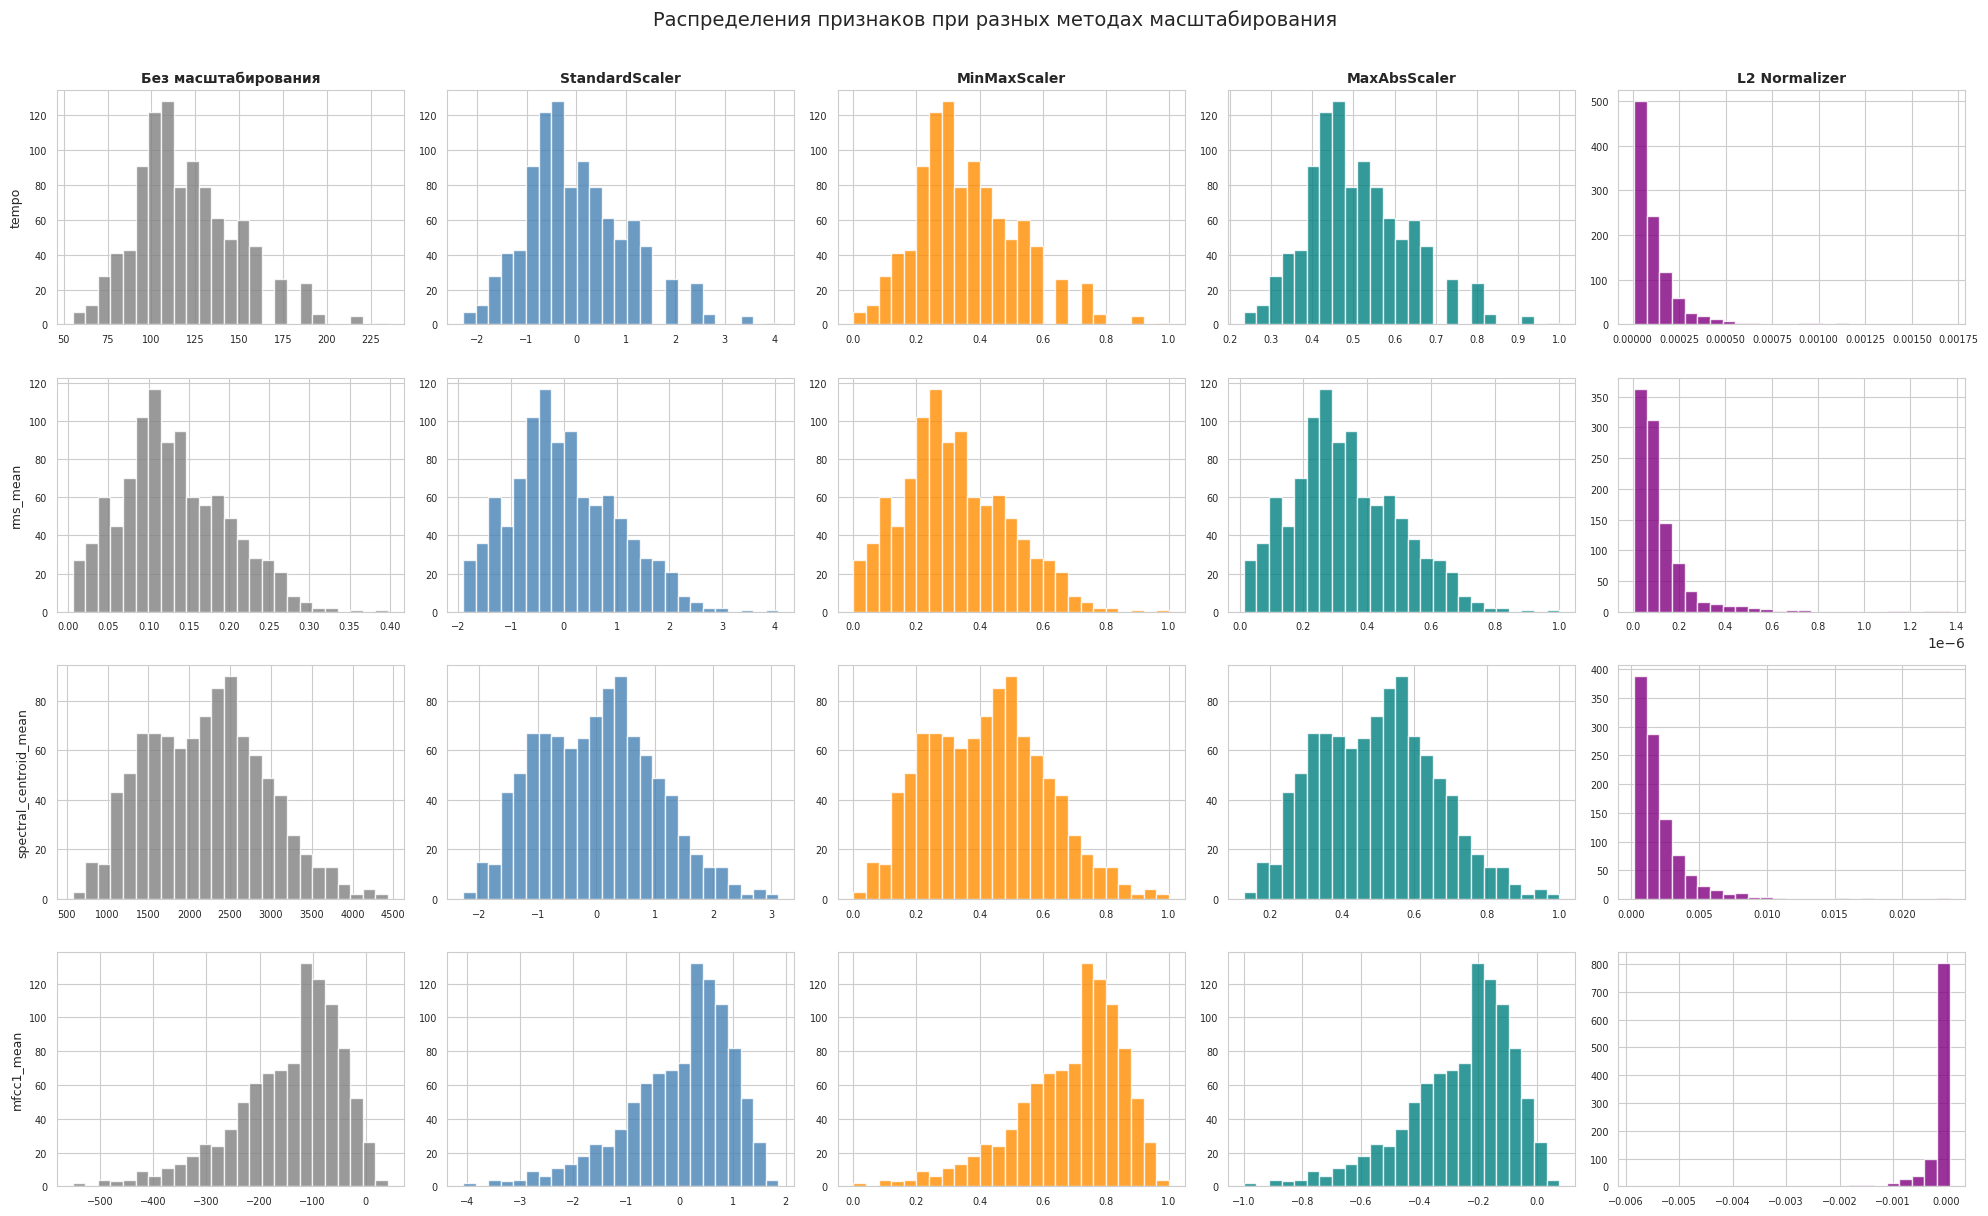

In [9]:
demo_features = ['tempo', 'rms_mean', 'spectral_centroid_mean', 'mfcc1_mean']
demo_idx = [num_cols.index(f) for f in demo_features]
scaler_names = list(scalers.keys())

fig, axes = plt.subplots(len(demo_features), len(scaler_names), figsize=(20, 12))

for i, feat_idx in enumerate(demo_idx):
    for j, sname in enumerate(scaler_names):
        ax = axes[i][j]
        ax.hist(scaled_data[sname][:, feat_idx], bins=25,
                color=['grey', 'steelblue', 'darkorange', 'teal', 'purple'][j],
                edgecolor='white', alpha=0.8)
        if i == 0:
            ax.set_title(sname, fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(demo_features[i], fontsize=9)
        ax.tick_params(labelsize=7)

fig.suptitle('Распределения признаков при разных методах масштабирования', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** StandardScaler центрирует данные вокруг нуля. MinMaxScaler сжимает в [0,1], сохраняя форму. MaxAbsScaler сохраняет знак. L2 Normalizer радикально меняет распределение, так как нормализует каждый *вектор наблюдения*, а не столбец.

### 2.3. Boxplot: сравнение масштабов

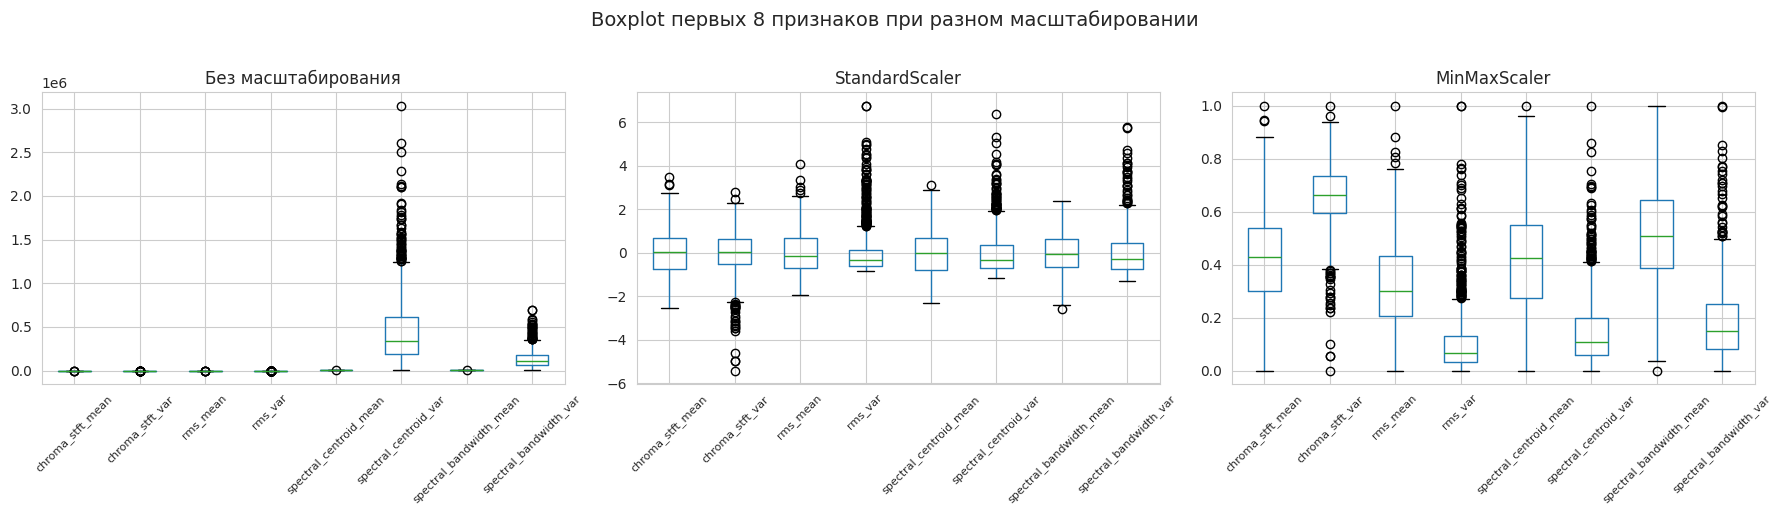

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sname in zip(axes, ['Без масштабирования', 'StandardScaler', 'MinMaxScaler']):
    d = pd.DataFrame(scaled_data[sname][:, :8], columns=num_cols[:8])
    d.boxplot(ax=ax, vert=True)
    ax.set_title(sname, fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('Boxplot первых 8 признаков при разном масштабировании', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Pipeline: масштабирование + классификатор

Pipeline объединяет предобработку и модель в единый конвейер, предотвращая утечку данных.

In [11]:
pipe_std = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000, random_state=42))])
pipe_mm = Pipeline([('scaler', MinMaxScaler()), ('clf', LogisticRegression(max_iter=5000, random_state=42))])
pipe_none = Pipeline([('clf', LogisticRegression(max_iter=5000, random_state=42))])

print('Pipelines созданы: без масштабирования, StandardScaler, MinMaxScaler')

Pipelines созданы: без масштабирования, StandardScaler, MinMaxScaler


---
## 4. Влияние масштабирования на качество классификации

Протестируем, как разные методы масштабирования влияют на accuracy трёх типов моделей:
- **LogisticRegression** — чувствительна к масштабу
- **KNN** — чувствителен (использует расстояния)
- **RandomForest** — нечувствителен к масштабу

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=5000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

scaler_options = {
    'Без масштаб.': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

results = []
for model_name, model in models.items():
    for scaler_name, scaler in scaler_options.items():
        if scaler is not None:
            pipe = Pipeline([('scaler', scaler), ('model', model)])
        else:
            pipe = Pipeline([('model', model)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        results.append({
            'Модель': model_name,
            'Скейлер': scaler_name,
            'Accuracy': scores.mean(),
            'Std': scores.std()
        })

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='Модель', columns='Скейлер', values='Accuracy').round(4)
print('Accuracy (5-fold CV):')
pivot

Accuracy (5-fold CV):


Скейлер,MaxAbsScaler,MinMaxScaler,StandardScaler,Без масштаб.
Модель,,,,
KNN (k=5),0.673,0.684,0.677,0.272
LogisticRegression,0.673,0.671,0.707,0.439
RandomForest,0.704,0.704,0.704,0.707


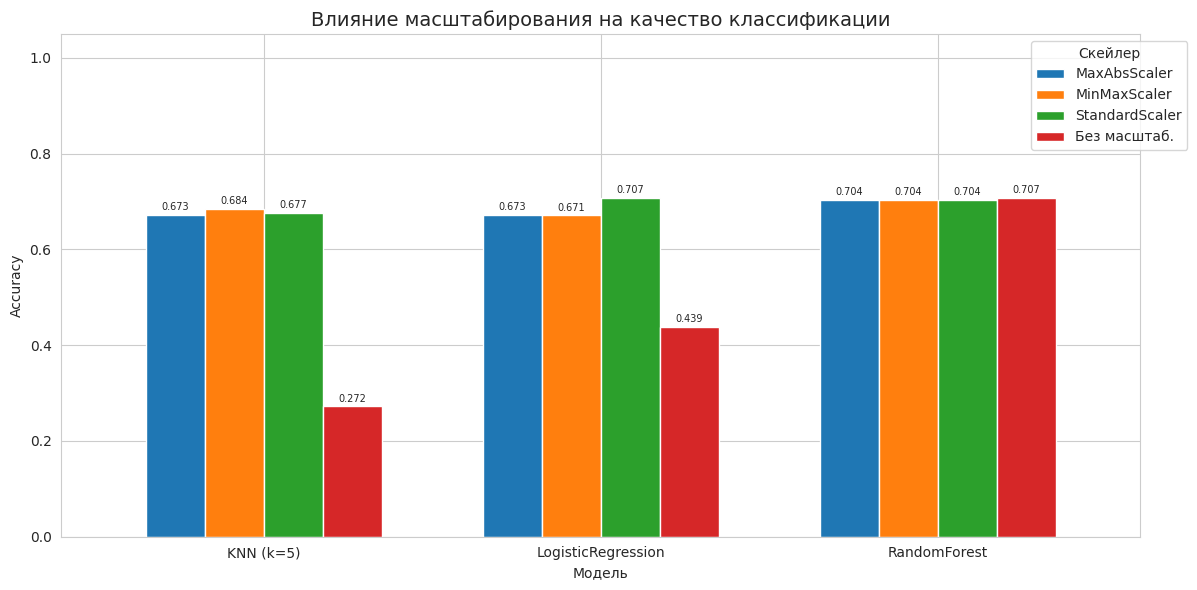

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_ylabel('Accuracy')
ax.set_title('Влияние масштабирования на качество классификации', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(title='Скейлер', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

**Интерпретация:**
- **LogisticRegression и KNN** значительно выигрывают от масштабирования.
- **RandomForest** практически не зависит от масштаба — деревья решений не чувствительны к масштабу.
- StandardScaler и MinMaxScaler дают схожие результаты для линейных моделей.

---
## Выводы

### Основные результаты:

1. **Кодирование:** Для целевой переменной `label` (10 жанров) продемонстрировали три метода — LabelEncoder, OrdinalEncoder и OneHotEncoder. Для задачи классификации оптимален LabelEncoder.

2. **Масштабирование:** Применили четыре метода (StandardScaler, MinMaxScaler, MaxAbsScaler, L2 Normalizer). Каждый по-разному преобразует распределение признаков.

3. **Влияние на модели:**
   - Масштабирование **критически важно** для LogisticRegression и KNN
   - Для **деревьев и ансамблей** масштабирование не влияет на результат
   - StandardScaler — универсальный выбор по умолчанию

4. **Pipeline** гарантирует корректное применение преобразований и предотвращает утечку данных при кросс-валидации.

### Практическое значение:

Для датасета GTZAN рекомендуется: LabelEncoder для жанра + StandardScaler для числовых признаков. В последующих лабораторных работах это будет применено в виде Pipeline.